In [ ]:
# --- Imports ---
import os
import zipfile
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import csv
import numpy as np
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0

# --- Constants ---
NUM_DRONES = 10
NUM_ROUNDS = 10
LOCAL_EPOCHS = 5
BATCH_SIZE = 32
BANDWIDTH_MBPS = 50
TARGET_LATENCY_MS = 90
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(42)
torch.manual_seed(42)


In [ ]:
# --- Step 1: Dataset Setup ---
os.environ['KAGGLE_CONFIG_DIR'] = os.getcwd()
kaggle_json_path = os.path.join(os.getcwd(), 'kaggle.json')
if os.path.exists(kaggle_json_path):
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    import shutil
    shutil.copy(kaggle_json_path, os.path.expanduser("~/.kaggle/kaggle.json"))
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
else:
    raise FileNotFoundError("Please place your kaggle.json file in the current directory.")

!kaggle datasets download -d yangpeng1995/rsscn7 -p ./data
with zipfile.ZipFile("./data/rsscn7.zip", 'r') as zip_ref:
    zip_ref.extractall("./data/rsscn7")

dataset_path = "./data/rsscn7/RSSCN7-master"

Dataset URL: https://www.kaggle.com/datasets/yangpeng1995/rsscn7
License(s): unknown
rsscn7.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# --- Transform and Load ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(dataset_path, transform=transform)

# Balanced Train-Test Split
test_size = 500
train_size = len(full_dataset) - test_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# Drone-wise splits
train_indices = list(range(len(train_dataset)))
random.shuffle(train_indices)
split_size = len(train_indices) // NUM_DRONES
splits = [train_indices[i*split_size:(i+1)*split_size] for i in range(NUM_DRONES)]

# Test loader
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [ ]:
# --- Step 3: Model Definition ---
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def create_model():
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)
    for param in model.features.parameters():
        param.requires_grad = True  # Fine-tune all layers
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 7)  # RSSCN7 has 7 classes
    return model.to(DEVICE)

In [ ]:
# --- Step 4: Router and VM classes
class Router:
    def __init__(self, threshold=0.10):  # Updated threshold
        self.threshold = threshold

    def inspect(self, image_tensor):
        return "yes" if image_tensor.mean().item() > self.threshold else "no"

class VM:
    def __init__(self):
        self.model = create_model()

    def process(self, image, label):
        self.model.eval()
        with torch.no_grad():
            image = image.unsqueeze(0).to(DEVICE)
            output = self.model(image)
            _, pred = torch.max(output, 1)
        return pred.item(), label

In [ ]:
# Drone Class
class Drone:
    def __init__(self, drone_id, indices):
        self.id = drone_id
        self.dataset = Subset(full_dataset, indices)
        self.loader = DataLoader(self.dataset, batch_size=BATCH_SIZE, shuffle=True)
        self.model = create_model()
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        self.images_used = 0
        print(f"Drone {drone_id+1} initialized with image tracking.")

    def local_train(self, epochs):
        router = Router()
        vm = VM()
        self.model.train()
        total_loss, steps = 0, 0
        used_images = 0

        for _ in range(epochs):
            for data, targets in self.loader:
                for i in range(len(data)):
                    image = data[i]
                    label = targets[i]
                    if router.inspect(image) == "yes":
                        pred, lbl = vm.process(image, label)
                        image = image.unsqueeze(0).to(DEVICE)
                        label = torch.tensor([label]).to(DEVICE)
                        self.optimizer.zero_grad()
                        output = self.model(image)
                        loss = self.criterion(output, label)
                        loss.backward()
                        self.optimizer.step()
                        total_loss += loss.item()
                        steps += 1
                        used_images += 1

        self.images_used = used_images
        return total_loss / steps if steps else 0

    def get_state(self):
        return {k: v.cpu().clone() for k, v in self.model.state_dict().items()}

    def set_state(self, state):
        self.model.load_state_dict(state)

    def evaluate(self):
        self.model.eval()
        correct = total = 0
        with torch.no_grad():
            for data, targets in test_loader:
                data, targets = data.to(DEVICE), targets.to(DEVICE)
                outputs = self.model(data)
                _, pred = torch.max(outputs, 1)
                correct += (pred == targets).sum().item()
                total += targets.size(0)
        return 100.0 * correct / total

In [ ]:
# Cloud and Fed Avg Class
class Cloud:
    def __init__(self):
        self.model_state = None

    def receive_model(self, state):
        size_mb = sum(p.numel() * 4 for p in state.values()) / 1e6
        noise = np.random.normal(1.0, 0.05)
        latency = (size_mb / BANDWIDTH_MBPS) * noise
        print(f" Cloud: Receiving aggregated model ({size_mb:.2f} MB, {latency*1000:.2f} ms)")
        time.sleep(latency)
        self.model_state = state.copy()
        return latency

    def distribute_model(self):
        return self.model_state.copy()

    def set_model(self, state):
        self.model_state = state.copy()

def fedavg(states):
    new_state = {}
    for k in states[0]:
        new_state[k] = sum(state[k] for state in states) / len(states)
    return new_state


In [ ]:
# --- Step 5: FogBroker Class with 3 Queues and Tracking ---
class FogBroker:
    def __init__(self, threshold_mb=16.5):
        self.threshold_mb = threshold_mb
        self.accepted_rounds = []
        self.total_models = []
        self.fitness_scores = []

    def filter_models(self, drone_states, drone_ids, drone_delays, drone_accuracies):
        valid, reprocess, drop = [], [], []
        valid_ids, reprocess_ids, drop_ids = [], [], []

        print("\n FogBroker Filtering:")
        for i, (state, delay, acc) in enumerate(zip(drone_states, drone_delays, drone_accuracies)):
            drone_id = drone_ids[i]
            size_mb = sum(p.numel() * 4 for p in state.values()) / 1e6 * np.random.uniform(0.95, 1.05)

            if size_mb <= self.threshold_mb:
                valid.append({
                    "drone_id": drone_id,
                    "state": state,
                    "accuracy": acc,
                    "total_delay": delay
                })
                valid_ids.append(drone_id)
                print(f" Drone {drone_id+1} → VALID | Size: {size_mb:.2f} MB | Acc: {acc:.2f}% | Delay: {delay*1000:.2f} ms")
            elif size_mb <= self.threshold_mb * 1.2:
                reprocess.append(state)
                reprocess_ids.append(drone_id)
                print(f" Drone {drone_id+1} → REPROCESS | Size: {size_mb:.2f} MB")
            else:
                drop.append(state)
                drop_ids.append(drone_id)
                print(f" Drone {drone_id+1} → DROPPED | Size: {size_mb:.2f} MB")

        # Track acceptance rate
        total_this_round = len(drone_states)
        self.total_models.append(total_this_round)
        self.accepted_rounds.append(len(valid))

        return valid, reprocess, drop, valid_ids, reprocess_ids, drop_ids
    def get_acceptance_rate(self):
        return self.accepted_rounds[-1] / self.total_models[-1] if self.total_models else 0

    def get_average_fitness(self):
        if not self.fitness_scores:
            return 0
        return sum(self.fitness_scores[-1]) / len(self.fitness_scores[-1]) if self.fitness_scores[-1] else 0


In [ ]:
# --- Step 7:  PSO Selection with Fitness & Optional Tracking ---

def compute_total_delay(model_state):
    size_mb = sum(p.numel() * 4 for p in model_state.values()) / 1e6
    transmission_delay = size_mb / BANDWIDTH_MBPS
    execution_delay = np.random.uniform(0.3, 0.6)  # Simulated local training delay
    return transmission_delay + execution_delay

def compute_fitness(acc, delay, max_delay, alpha=1.0, beta=0.05):
    return (alpha * (1 - acc / 100)) + (beta * (delay / max_delay))

def pso_select_models(valid_info, alpha=1.0, beta=0.05, num_select=3, fog=None):
    num_particles = len(valid_info)
    if num_particles <= num_select:
        return valid_info

    max_delay = max(info['total_delay'] for info in valid_info)

    particles = []
    fitness_scores = []
    for info in valid_info:
        fitness = compute_fitness(info['accuracy'], info['total_delay'], max_delay, alpha, beta)
        particles.append(info)
        fitness_scores.append(fitness)

    # Sort models based on lowest fitness
    sorted_particles = [p for _, p in sorted(zip(fitness_scores, particles), key=lambda x: x[0])]

    # Store fitness scores for trend plotting
    if fog is not None:
        fog.fitness_scores.append(fitness_scores[:3])  # Store top 3

    return sorted_particles[:num_select]


In [ ]:
# --- System Cost Coefficients ---
CPU_RATE = 0.5        # Cost per second of CPU usage
MEMORY_RATE = 0.1     # Cost per MB of memory usage
BANDWIDTH_RATE = 0.05 # Cost per MB of bandwidth usage

drones = [Drone(i, splits[i]) for i in range(NUM_DRONES)]
cloud = Cloud()
logs = []
global_accs = []

routerA_ids = list(range(5))
routerB_ids = list(range(5, 10))

alpha = 1.0
beta = 0.05

for rnd in range(1, NUM_ROUNDS + 1):
    print(f"\n================ Round {rnd} ================\n")
    local_states = [None] * NUM_DRONES
    losses = [None] * NUM_DRONES
    round_latency = 0.0
    model_infos = []

    for i, drone in enumerate(drones):
        print(f"Drone {i+1} training...")
        loss = drone.local_train(LOCAL_EPOCHS)
        state = drone.get_state()
        exec_time = np.random.uniform(0.4, 0.6)
        model_size_mb = sum(p.numel() * 4 for p in state.values()) / 1e6 * np.random.uniform(0.95, 1.05)
        transmission_delay = (model_size_mb / BANDWIDTH_MBPS) * np.random.normal(1.0, 0.05)
        total_delay = exec_time + transmission_delay
        round_latency += total_delay
        acc = drone.evaluate()

        local_states[i] = state
        losses[i] = loss

        cost = (CPU_RATE * exec_time) + (MEMORY_RATE * model_size_mb) + (BANDWIDTH_RATE * model_size_mb)

        model_infos.append({
            "drone_id": i,
            "state": state,
            "accuracy": acc / 100.0,
            "total_delay": total_delay,
            "cost": cost
        })

        print(f"  Loss: {loss:.4f}, Accuracy: {acc:.2f}%, Delay: {total_delay * 1000:.2f} ms")

    # --- Fog Filtering ---
    fogA = FogBroker(threshold_mb=18.0)
    fogB = FogBroker(threshold_mb=18.0)

    valid_A, _, _, valid_ids_A, _, _ = fogA.filter_models(
        [local_states[i] for i in routerA_ids], routerA_ids,
        [model_infos[i]["total_delay"] for i in routerA_ids],
        [model_infos[i]["accuracy"] for i in routerA_ids]
    )
    valid_B, _, _, valid_ids_B, _, _ = fogB.filter_models(
        [local_states[i] for i in routerB_ids], routerB_ids,
        [model_infos[i]["total_delay"] for i in routerB_ids],
        [model_infos[i]["accuracy"] for i in routerB_ids]
    )

    model_infos_A = [model_infos[i] for i in valid_ids_A]
    model_infos_B = [model_infos[i] for i in valid_ids_B]

    print("\n PSO selecting top 3 models from Router A")
    top_A = pso_select_models(model_infos_A, alpha, beta, num_select=3, fog=fogA)
    print(" Selected drones from Router A:", [info['drone_id'] + 1 for info in top_A])
    agg_A = fedavg([info["state"] for info in top_A]) if top_A else None

    print("\n PSO selecting top 3 models from Router B")
    top_B = pso_select_models(model_infos_B, alpha, beta, num_select=3, fog=fogB)
    print(" Selected drones from Router B:", [info['drone_id'] + 1 for info in top_B])
    agg_B = fedavg([info["state"] for info in top_B]) if top_B else None

    if agg_A and agg_B:
        print("\n  Cloud aggregating filtered updates...")
        agg_cloud = fedavg([agg_A, agg_B])
        cloud_latency = cloud.receive_model(agg_cloud)
        round_latency += cloud_latency
        cloud.set_model(agg_cloud)
        updated_state = cloud.distribute_model()
        for drone in drones:
            drone.set_state(updated_state)

        # Evaluate the global model (after aggregation)
        temp_model = create_model()
        temp_model.load_state_dict(updated_state)
        temp_model.to(DEVICE)
        temp_model.eval()

        correct = 0
        total = 0
        with torch.no_grad():
            for data, targets in test_loader:
                data, targets = data.to(DEVICE), targets.to(DEVICE)
                outputs = temp_model(data)
                _, pred = torch.max(outputs, 1)
                correct += (pred == targets).sum().item()
                total += targets.size(0)

        acc = 100.0 * correct / total
        global_accs.append(acc)
        print(f" Aggregated Global Model Accuracy: {acc:.2f}%")

        avg_cost = np.mean([info["cost"] for info in model_infos])
        acceptance_A = fogA.get_acceptance_rate()
        acceptance_B = fogB.get_acceptance_rate()
        avg_fitness_A = fogA.get_average_fitness()
        avg_fitness_B = fogB.get_average_fitness()

        logs.append([
            rnd,
            acc,
            round_latency * 1000,
            cloud_latency * 1000,
            avg_cost,
            acceptance_A,
            acceptance_B,
            avg_fitness_A,
            avg_fitness_B
        ] + losses)
    else:
        print("  Aggregation failed due to no valid models.")


Drone 1 initialized with image tracking.
Drone 2 initialized with image tracking.
Drone 3 initialized with image tracking.
Drone 4 initialized with image tracking.
Drone 5 initialized with image tracking.
Drone 6 initialized with image tracking.
Drone 7 initialized with image tracking.
Drone 8 initialized with image tracking.
Drone 9 initialized with image tracking.
Drone 10 initialized with image tracking.

================ Round 1 ================

Drone 1 training...
  Loss: 0.9877, Accuracy: 19.80%, Delay: 754.43 ms
Drone 2 training...
  Loss: 1.0007, Accuracy: 10.00%, Delay: 813.85 ms
Drone 3 training...
  Loss: 0.7666, Accuracy: 9.60%, Delay: 746.17 ms
Drone 4 training...
  Loss: 1.0829, Accuracy: 21.00%, Delay: 750.57 ms
Drone 5 training...
  Loss: 1.0215, Accuracy: 21.20%, Delay: 782.08 ms
Drone 6 training...
  Loss: 1.0840, Accuracy: 18.60%, Delay: 911.20 ms
Drone 7 training...
  Loss: 0.8038, Accuracy: 14.00%, Delay: 721.65 ms
Drone 8 training...
  Loss: 1.0722, Accuracy: 7.6

In [ ]:
# --- Step 8: Save Logs to CSV ---
csv_path = "./fed_pso_effnetb0_logs.csv"

with open(csv_path, "w", newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["Round", "Global Acc", "Total Latency (ms)", "Cloud Latency (ms)","Average Cost", "Acceptance A", "Acceptance B", "Fitness A", "Fitness B"] +
                    [f"Drone {i+1} Loss" for i in range(NUM_DRONES)])
    writer.writerows(logs)

print(f" Logs saved to {csv_path}")

 Logs saved to ./fed_pso_effnetb0_logs.csv


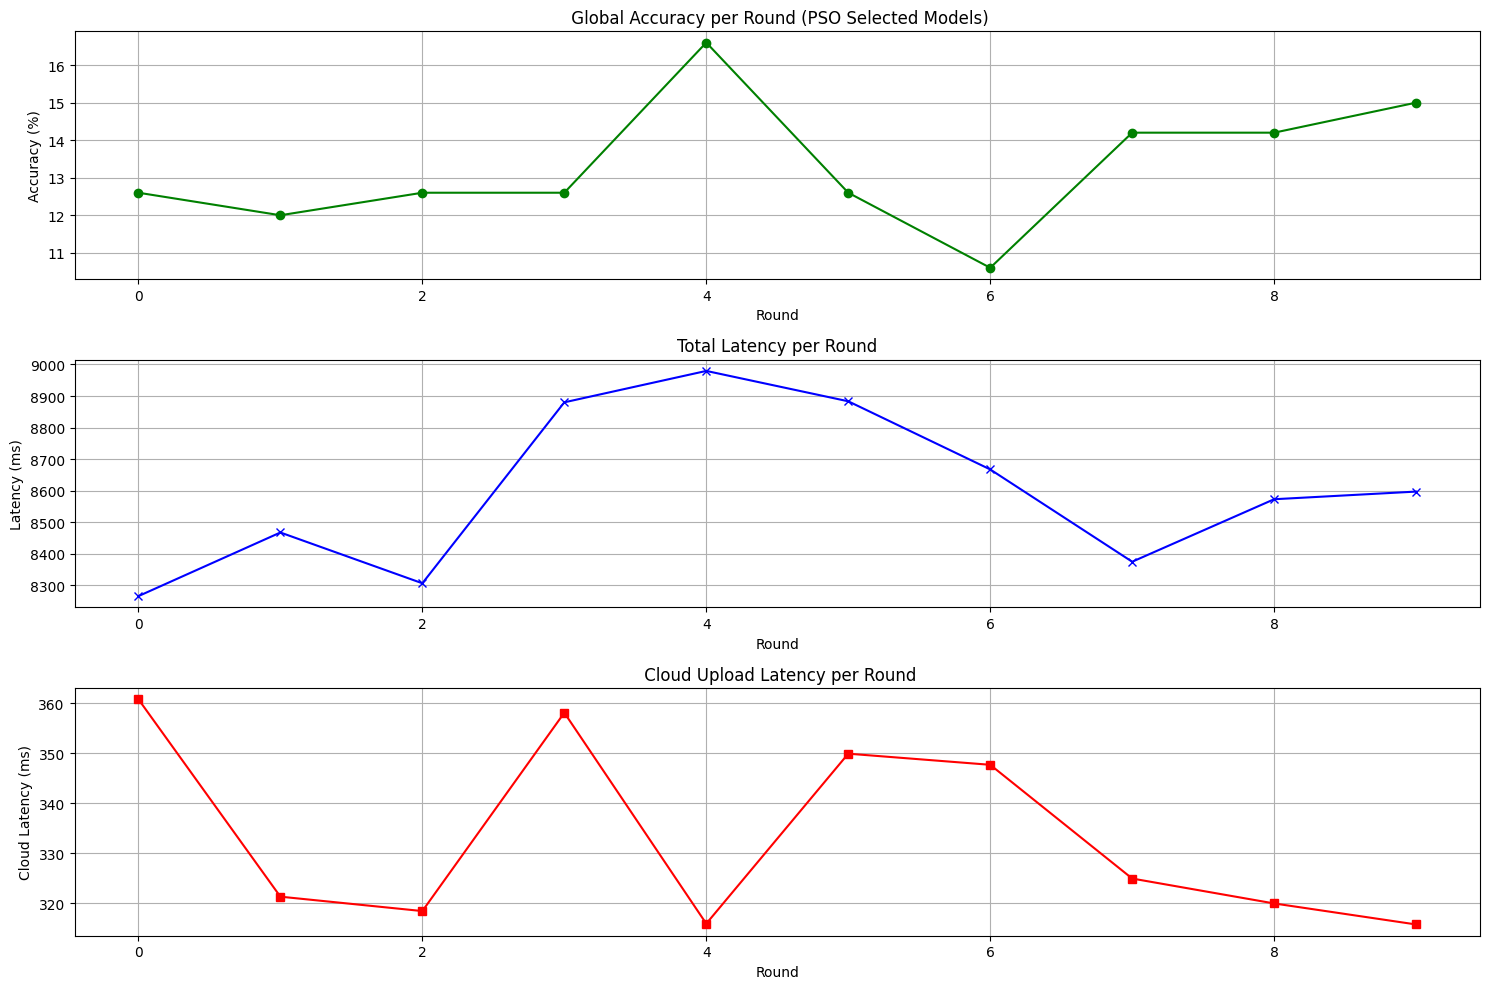

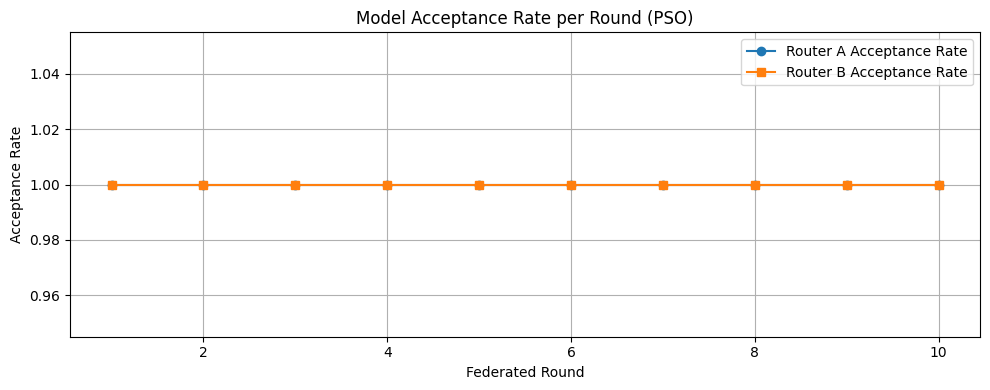

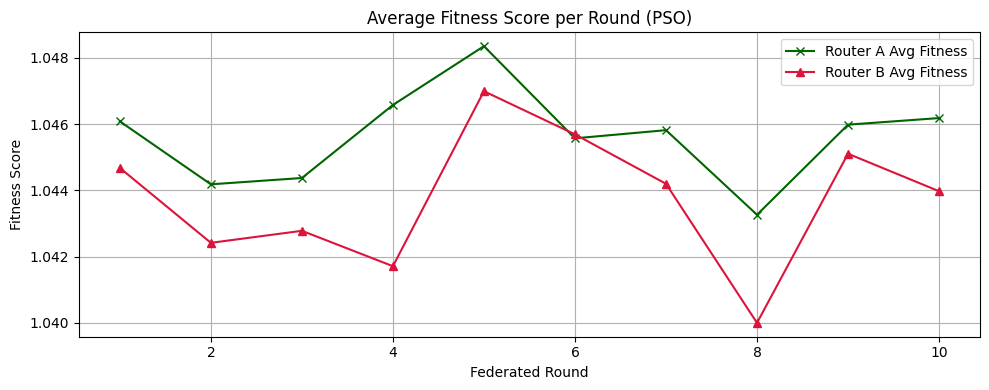

In [ ]:
# --- Step 8: Plot Accuracy and Latency ---
plt.figure(figsize=(15, 10))

# Accuracy
plt.subplot(3, 1, 1)
plt.plot(global_accs, marker='o', color='green')
plt.title(" Global Accuracy per Round (PSO Selected Models)")
plt.xlabel("Round")
plt.ylabel("Accuracy (%)")
plt.grid(True)

# Total Latency
total_latency_ms = [row[2] for row in logs]
plt.subplot(3, 1, 2)
plt.plot(total_latency_ms, marker='x', color='blue')
plt.title("Total Latency per Round")
plt.xlabel("Round")
plt.ylabel("Latency (ms)")
plt.grid(True)

# Cloud Latency
cloud_latency_ms = [row[3] for row in logs]
plt.subplot(3, 1, 3)
plt.plot(cloud_latency_ms, marker='s', color='red')
plt.title(" Cloud Upload Latency per Round")
plt.xlabel("Round")
plt.ylabel("Cloud Latency (ms)")
plt.grid(True)

plt.tight_layout()
plt.show()

# Extracting acceptance and fitness scores from logs
acceptance_A = [row[5] for row in logs]
acceptance_B = [row[6] for row in logs]
avg_fit_A = [row[7] for row in logs]
avg_fit_B = [row[8] for row in logs]

rounds = list(range(1, NUM_ROUNDS + 1))
# Acceptance rate
plt.figure(figsize=(10, 4))
plt.plot(rounds, acceptance_A, marker='o', label='Router A Acceptance Rate')
plt.plot(rounds, acceptance_B, marker='s', label='Router B Acceptance Rate')
plt.title("Model Acceptance Rate per Round (PSO)")
plt.xlabel("Federated Round")
plt.ylabel("Acceptance Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Fitness Score
plt.figure(figsize=(10, 4))
plt.plot(rounds, avg_fit_A, marker='x', color='darkgreen', label='Router A Avg Fitness')
plt.plot(rounds, avg_fit_B, marker='^', color='crimson', label='Router B Avg Fitness')
plt.title("Average Fitness Score per Round (PSO)")
plt.xlabel("Federated Round")
plt.ylabel("Fitness Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
